# 01 · Dimensionality Reduction: PCA, t-SNE, UMAP & Autoencoders

**Phase 6 — Section 6.2 Dimensionality Reduction | Notebook 1 of 1**

### Why this matters
You can't plot 13 dimensions. You can't always cluster or model them well either (recall
Section 4.1's curse of dimensionality). This notebook covers four ways to compress many
features down to a handful, each with a genuinely different philosophy — from Module 1.1's
linear PCA all the way to a trained neural network.

### The real dataset: Wine

178 real wine samples, each described by 13 chemical measurements, and a known cultivar
(1, 2, or 3) — perfect for checking whether dimensionality reduction actually preserves the
TRUE structure, since we can compare against ground truth.

```
https://raw.githubusercontent.com/rasbt/python-machine-learning-book/master/code/datasets/wine/wine.data
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/rasbt/python-machine-learning-book/master/code/datasets/wine/wine.data"
columns = ["cultivar", "alcohol", "malic_acid", "ash", "alcalinity_of_ash", "magnesium",
           "total_phenols", "flavanoids", "nonflavanoid_phenols", "proanthocyanins",
           "color_intensity", "hue", "od280_od315", "proline"]
df = pd.read_csv(url, names=columns)
print(df.shape)
df.head()

(178, 14)


,cultivar,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## 0. Why 13 features is already "too many to see"

In [2]:
feature_cols = [c for c in columns if c != "cultivar"]
print(f"{len(feature_cols)} features -- C(13,2) = {13*12//2} possible pairwise scatter plots")
print("Nobody looks at 78 scatter plots one at a time. We need to compress first.")

from sklearn.preprocessing import StandardScaler
X = df[feature_cols].values
y = df["cultivar"].values
X_scaled = StandardScaler().fit_transform(X)

13 features -- C(13,2) = 78 possible pairwise scatter plots
Nobody looks at 78 scatter plots one at a time. We need to compress first.


## 1. PCA — Module 1.1's linear projection, revisited

You derived PCA from scratch in Module 1.1: center the data, eigen-decompose the
covariance matrix, project onto the top eigenvectors. Here it is as a one-line, real tool.

variance explained by PC1: 36.2%
variance explained by PC2: 19.2%
total (2 components, from 13 original features): 55.4%


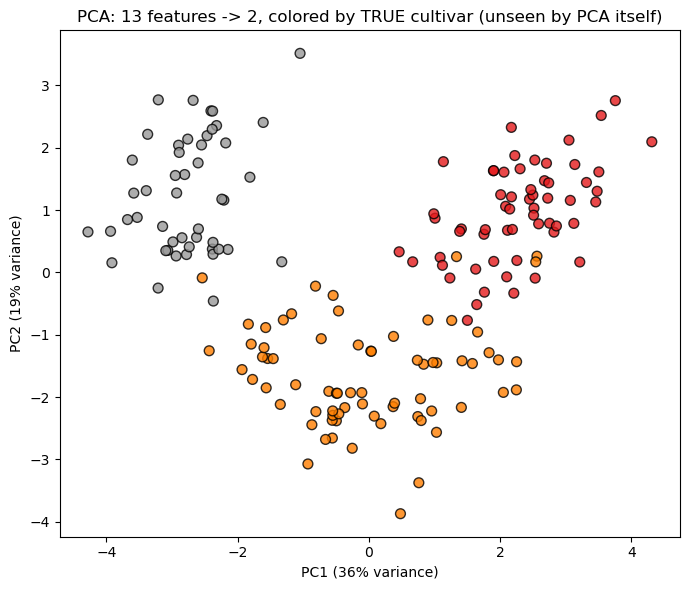

In [3]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"variance explained by PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"variance explained by PC2: {pca.explained_variance_ratio_[1]:.1%}")
print(f"total (2 components, from 13 original features): {pca.explained_variance_ratio_[:2].sum():.1%}")

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="Set1", s=50, edgecolor="k", alpha=0.8)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} variance)")
ax.set_title("PCA: 13 features -> 2, colored by TRUE cultivar (unseen by PCA itself)")
plt.tight_layout(); plt.show()

> 💡 **PCA never saw the cultivar labels** — it only looked at variance in the 13
> chemical measurements. The fact that the 3 true cultivars still separate this cleanly is
> strong evidence that most of the wine's "chemical identity" lives in just 2 combined
> dimensions.

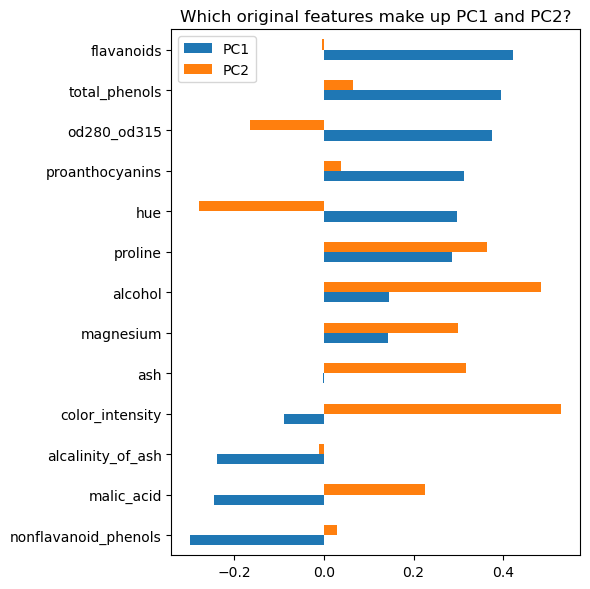

In [4]:
loadings = pd.DataFrame(pca.components_.T, index=feature_cols, columns=["PC1", "PC2"])
fig, ax = plt.subplots(figsize=(6, 6))
loadings.sort_values("PC1").plot(kind="barh", ax=ax)
ax.set_title("Which original features make up PC1 and PC2?")
plt.tight_layout(); plt.show()

## 2. t-SNE — a non-linear map built to preserve LOCAL neighborhoods

PCA optimizes for variance globally, along straight lines. **t-SNE** instead tries to keep
points that were close in the original 13D space close in the 2D map — even if that
requires bending and stretching non-linearly. It's built for visualization, not general
preprocessing.

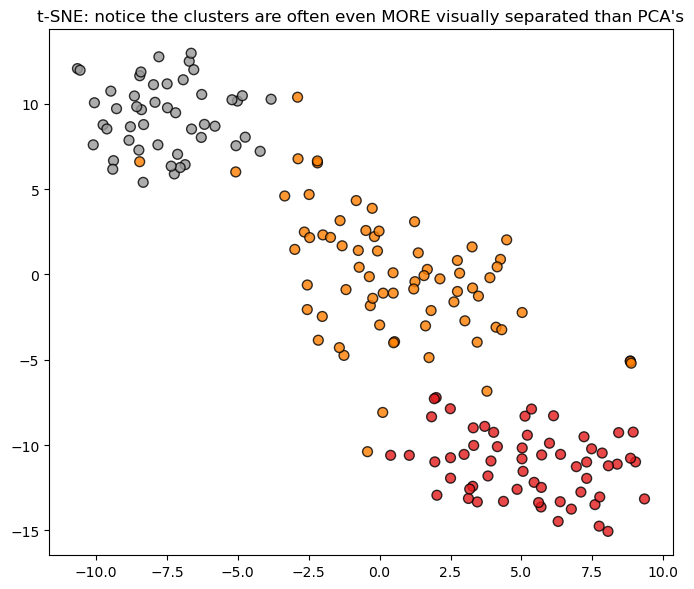

In [5]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="Set1", s=50, edgecolor="k", alpha=0.8)
ax.set_title("t-SNE: notice the clusters are often even MORE visually separated than PCA's")
plt.tight_layout(); plt.show()

> ⚠️ **A famous t-SNE trap:** distances BETWEEN clusters, and cluster SIZES, are not
> meaningful in a t-SNE plot — only which points ended up near each other locally. Never
> conclude "cluster A is twice as spread out as cluster B" or "cluster A is much further
> from C than from B" from a t-SNE plot alone. `perplexity` (roughly, "how many neighbors
> to consider") is t-SNE's most important hyperparameter — try several values on real data.

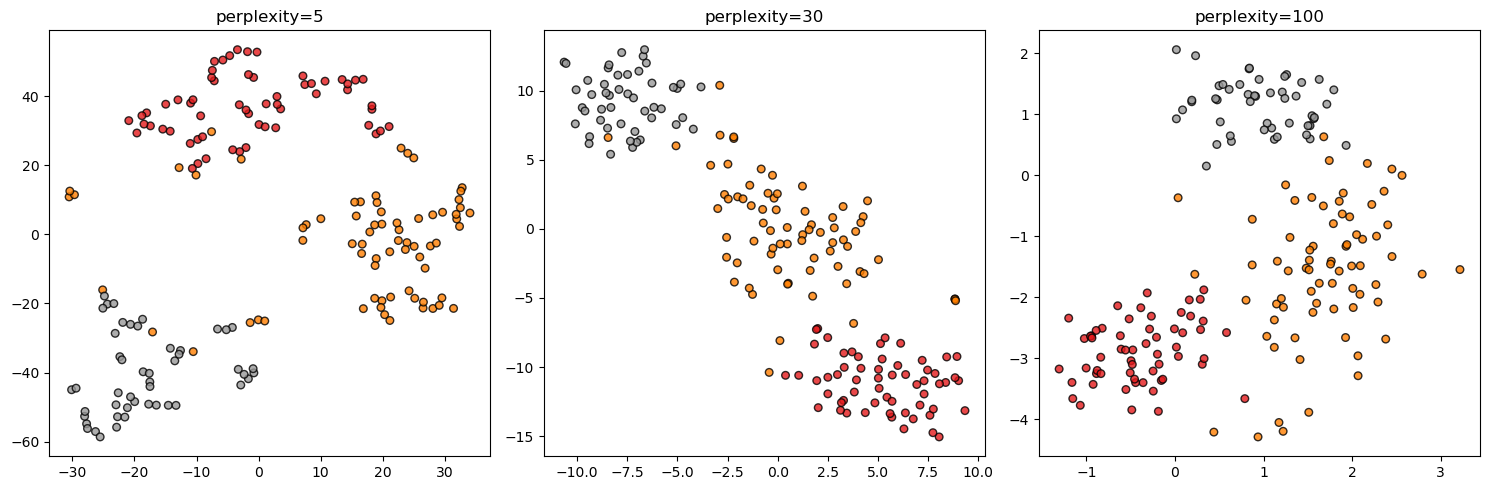

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, perplexity in zip(axes, [5, 30, 100]):
    tsne_p = TSNE(n_components=2, perplexity=perplexity, random_state=42, init="pca")
    X_t = tsne_p.fit_transform(X_scaled)
    ax.scatter(X_t[:, 0], X_t[:, 1], c=y, cmap="Set1", s=30, edgecolor="k", alpha=0.8)
    ax.set_title(f"perplexity={perplexity}")
plt.tight_layout(); plt.show()

## 3. UMAP — faster, often better global structure than t-SNE

UMAP is built on different mathematical foundations (topology-based) but solves a similar
problem to t-SNE — typically faster on large datasets and often better at preserving some
global structure (e.g. relative distances between clusters) alongside local neighborhoods.

In [ ]:
! pip install umap-learn

C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


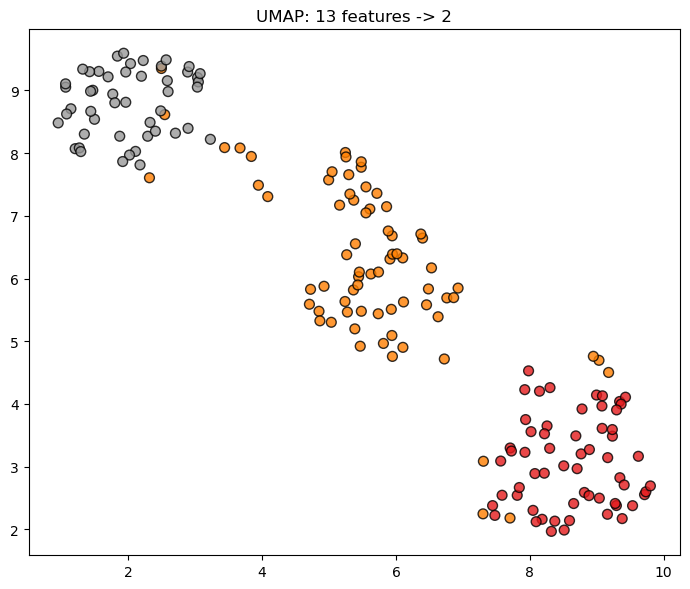

In [7]:
import umap

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap="Set1", s=50, edgecolor="k", alpha=0.8)
ax.set_title("UMAP: 13 features -> 2")
plt.tight_layout(); plt.show()

| | PCA | t-SNE | UMAP |
|---|---|---|---|
| Linear? | Yes | No | No |
| Preserves | Global variance | Local neighborhoods | Local + some global structure |
| Speed | Very fast | Slow on large data | Fast, scales better than t-SNE |
| Can transform NEW points after fitting? | Yes | No (must refit) | Yes |
| Best for | General preprocessing, interpretable axes | Visualization only | Visualization + some preprocessing use |

## 4. Autoencoders — a neural network that learns its own compression

An autoencoder is a neural network trained to reconstruct its own input, but forced
through a narrow "bottleneck" layer in the middle — that bottleneck IS the compressed
representation, learned entirely from data rather than a fixed formula like PCA's.

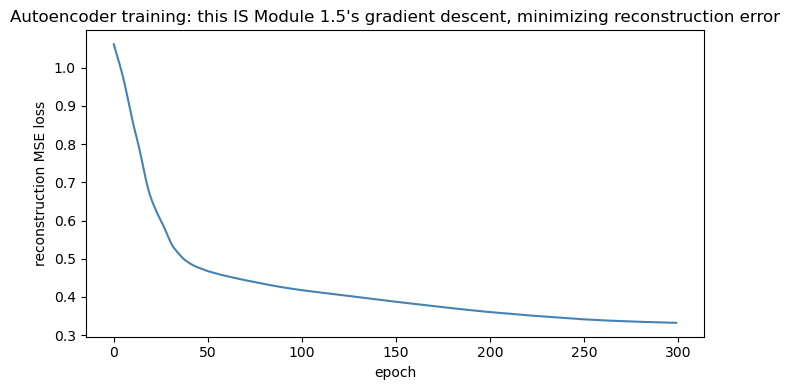

In [8]:
import torch
import torch.nn as nn

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

class Autoencoder(nn.Module):
    def __init__(self, n_features, bottleneck_dim=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_features, 8), nn.ReLU(),
            nn.Linear(8, bottleneck_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 8), nn.ReLU(),
            nn.Linear(8, n_features),
        )

    def forward(self, x):
        z = self.encoder(x)
        reconstructed = self.decoder(z)
        return reconstructed, z

torch.manual_seed(42)
model = Autoencoder(n_features=X_scaled.shape[1], bottleneck_dim=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

losses = []
for epoch in range(300):
    optimizer.zero_grad()
    reconstructed, _ = model(X_tensor)
    loss = loss_fn(reconstructed, X_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(losses, color="steelblue")
ax.set_xlabel("epoch"); ax.set_ylabel("reconstruction MSE loss")
ax.set_title("Autoencoder training: this IS Module 1.5's gradient descent, minimizing reconstruction error")
plt.tight_layout(); plt.show()

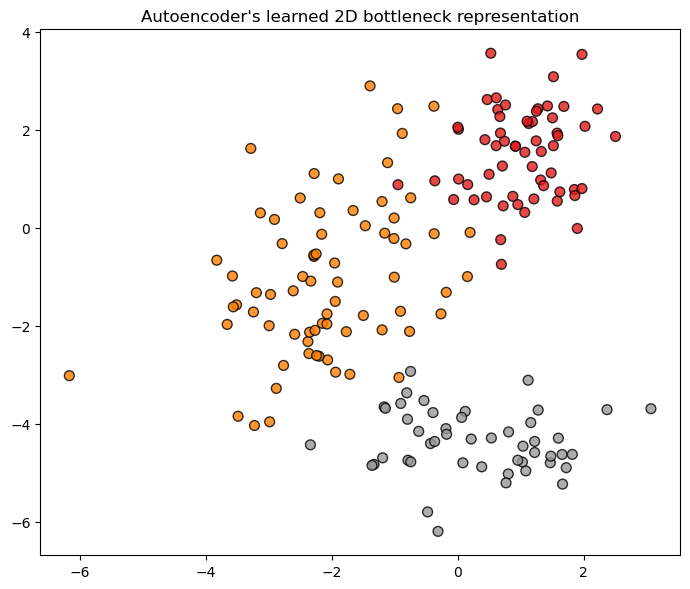

In [9]:
with torch.no_grad():
    _, X_autoencoded = model(X_tensor)
X_autoencoded = X_autoencoded.numpy()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_autoencoded[:, 0], X_autoencoded[:, 1], c=y, cmap="Set1", s=50, edgecolor="k", alpha=0.8)
ax.set_title("Autoencoder's learned 2D bottleneck representation")
plt.tight_layout(); plt.show()

> 💡 **Why bother with an autoencoder when PCA is simpler and faster?** PCA can only find
> LINEAR combinations of features. An autoencoder's hidden layers (with non-linear
> activations like ReLU) can learn arbitrarily non-linear compressions — at the cost of
> needing more data and careful training. On this small, simple dataset PCA already does
> great; autoencoders earn their complexity on much larger, more non-linearly-structured
> data (e.g. images in Phase 10, where a plain PCA would do very poorly).

## 5. Side-by-side comparison

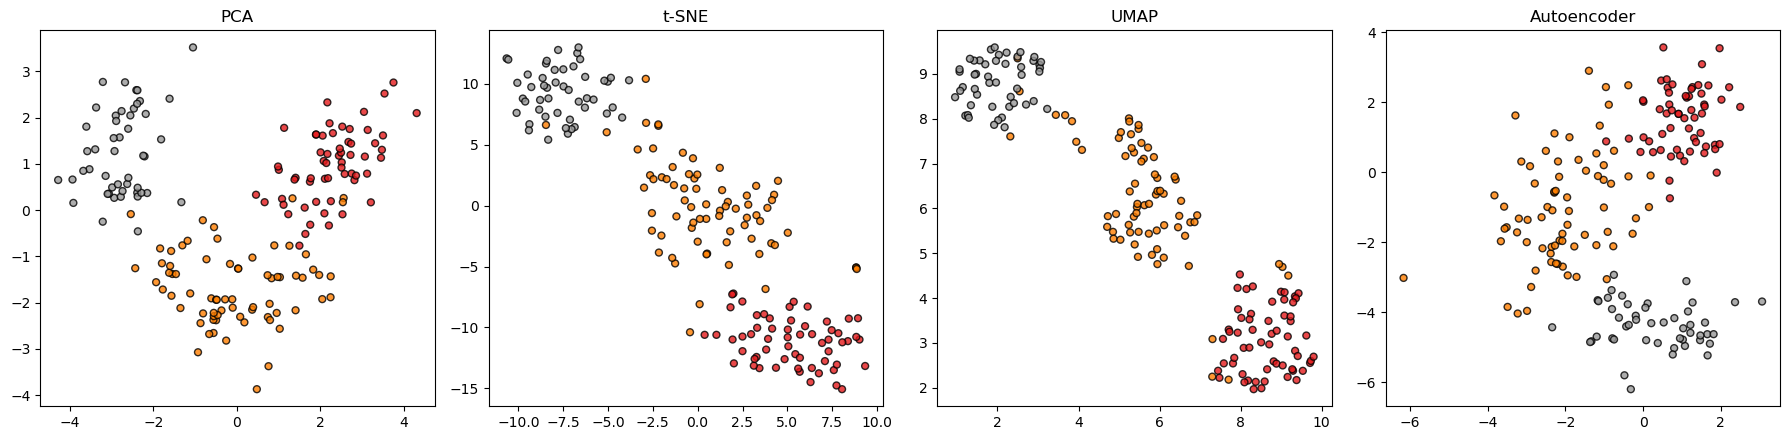

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, (data, title) in zip(axes, [
    (X_pca, "PCA"), (X_tsne, "t-SNE"), (X_umap, "UMAP"), (X_autoencoded, "Autoencoder"),
]):
    ax.scatter(data[:, 0], data[:, 1], c=y, cmap="Set1", s=25, edgecolor="k", alpha=0.8)
    ax.set_title(title)
plt.tight_layout(); plt.show()

## 🧪 Practice Exercises

**1.** Using `pca.explained_variance_ratio_`, find how many components you'd need to keep
to retain at least 95% of the total variance (hint: `np.cumsum`).

**2.** Re-run UMAP with `n_neighbors=5` and `n_neighbors=50`. How does the plot's structure
change, similar to t-SNE's `perplexity`?

**3.** Increase the autoencoder's bottleneck from 2 to 3 dimensions, retrain, and check
whether the final reconstruction loss improves — does this match your intuition about
compressing to fewer vs. more dimensions?

In [ ]:
# --- Exercise 1 ---
pca_full = PCA().fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components needed for 95% variance: {n_components_95} (out of 13 original features)")

In [ ]:
# --- Exercise 2 ---
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, n in zip(axes, [5, 50]):
    r = umap.UMAP(n_neighbors=n, min_dist=0.1, random_state=42)
    X_u = r.fit_transform(X_scaled)
    ax.scatter(X_u[:, 0], X_u[:, 1], c=y, cmap="Set1", s=30, edgecolor="k")
    ax.set_title(f"n_neighbors={n}")
plt.tight_layout(); plt.show()

In [ ]:
# --- Exercise 3 ---
torch.manual_seed(42)
model_3d = Autoencoder(n_features=X_scaled.shape[1], bottleneck_dim=3)
optimizer_3d = torch.optim.Adam(model_3d.parameters(), lr=0.01)
for epoch in range(300):
    optimizer_3d.zero_grad()
    reconstructed, _ = model_3d(X_tensor)
    loss = loss_fn(reconstructed, X_tensor)
    loss.backward()
    optimizer_3d.step()

print(f"final loss, 2D bottleneck: {losses[-1]:.4f}")
print(f"final loss, 3D bottleneck: {loss.item():.4f}")
print("\nMore bottleneck dimensions -> less information must be discarded -> lower")
print("reconstruction error, generally -- the same tradeoff as PCA's variance-vs-components curve.")

---
### ✅ Checkpoint — Section 6.2 complete!
You should now be able to:
- Use PCA and interpret explained variance / loadings
- Explain what t-SNE optimizes for, and why its distances between clusters aren't
  meaningful
- Explain UMAP's practical advantages over t-SNE
- Build and train a basic autoencoder, and explain when its non-linearity earns its
  complexity over PCA

**Next section:** `03-anomaly-detection` — using density and isolation ideas to find the
points that DON'T belong.